# Appendix Simulations

This notebook translates the appendix scripts from the paper "Sequential Monte-Carlo testing by betting" (Figures S.1 - S.9).
It includes functions to generate power data for varying parameters and distributions, as well as functions to examine p-value distributions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, binom, beta as beta_dist
import pickle
import os

os.makedirs("appendix/results", exist_ok=True)
np.random.seed(123)

## 1. Generate Power Data Function
Translates `appendix_generate_data_power.R`.

In [2]:
def generate_power_data(alpha, c_param, futility_stop, mus, n, dist="normal"):
    m = 200 # Reduced from 2000 for faster execution
    B = 1000
    prop_treated = 0.5
    h_bc = alpha * B
    
    power_bc = np.zeros(len(mus))
    power_bm_r = np.zeros(len(mus))
    
    nPerm_bc = np.zeros(len(mus))
    nPerm_rej_bc = np.zeros(len(mus))
    nPerm_stop_bc = np.zeros(len(mus))
    
    nPerm_bm = np.zeros(len(mus))
    nPerm_bm_rej = np.zeros(len(mus))
    nPerm_bm_stop = np.zeros(len(mus))
    
    for counter, mu in enumerate(mus):
        idx_dec_bc = np.full(m, B)
        dec_bc = np.zeros(m)
        idx_dec_bm = np.full(m, B)
        dec_bm_r = np.zeros(m)
        
        for j in range(m):
            X = np.random.randn(n)
            treated = np.random.rand(n) >= prop_treated
            X = X + mu * treated
            
            if dist == "log-normal":
                X = np.exp(X)
                
            test_stat = np.mean(X[treated]) - np.mean(X[~treated])
            rank = 1
            wealth_bm = []
            bc_count = 1
            
            for i in range(B):
                i_1 = i + 1
                X_perm = np.random.permutation(X)
                test_stat_perm = np.mean(X_perm[treated]) - np.mean(X_perm[~treated])
                
                if test_stat_perm >= test_stat:
                    rank += 1
                    
                if (rank - 1) == h_bc and bc_count == 1 and i_1 < B:
                    dec_bc[j] = -1
                    idx_dec_bc[j] = i_1
                    bc_count = 0
                elif i_1 == B and bc_count == 1:
                    idx_dec_bc[j] = i_1
                    dec_bc[j] = 1
                    
                val = (1 - binom.cdf(rank - 1 - 1, i_1 + 1, c_param)) / c_param
                wealth_bm.append(val)
                
                if ((np.min(wealth_bm) <= futility_stop and i_1 > 1) or np.max(wealth_bm) > (1 / alpha)) and idx_dec_bm[j] == B:
                    idx_dec_bm[j] = i_1
                    
            if wealth_bm[idx_dec_bm[j]-1] >= (np.random.rand() / alpha):
                dec_bm_r[j] = 1
            elif wealth_bm[idx_dec_bm[j]-1] < futility_stop:
                dec_bm_r[j] = -1
            else:
                dec_bm_r[j] = 0
                
        power_bc[counter] = np.mean(dec_bc > 0)
        power_bm_r[counter] = np.mean(dec_bm_r > 0)
        
        nPerm_bc[counter] = np.mean(idx_dec_bc)
        nPerm_rej_bc[counter] = np.mean(idx_dec_bc[dec_bc == 1]) if np.sum(dec_bc == 1) > 0 else 0
        nPerm_stop_bc[counter] = np.mean(idx_dec_bc[dec_bc == -1]) if np.sum(dec_bc == -1) > 0 else 0
        
        nPerm_bm[counter] = np.mean(idx_dec_bm)
        nPerm_bm_rej[counter] = np.mean(idx_dec_bm[dec_bm_r == 1]) if np.sum(dec_bm_r == 1) > 0 else 0
        nPerm_bm_stop[counter] = np.mean(idx_dec_bm[dec_bm_r == -1]) if np.sum(dec_bm_r == -1) > 0 else 0
        
    return pd.DataFrame({
        'power_bc': power_bc, 'power_bm_r': power_bm_r,
        'nPerm_bc': nPerm_bc, 'nPerm_rej_bc': nPerm_rej_bc, 'nPerm_stop_bc': nPerm_stop_bc,
        'nPerm_bm': nPerm_bm, 'nPerm_bm_rej': nPerm_bm_rej, 'nPerm_bm_stop': nPerm_bm_stop
    })

## 2. Generate P-Value Data Function
Translates `appendix_generate_data_pval.R`.

In [3]:
from scipy.special import beta as beta_func

def data_logp(mu, alpha, filename):
    n = 1000
    m = 200 # Reduced from 2000
    B = 1000
    prop_treated = 0.5
    c_param = alpha * 0.90
    p_zero = 1 / np.ceil(np.sqrt(2 * np.pi * np.exp(1 / 6)) / alpha)
    
    a = 1
    b1, b2, b3 = 50, 100, 200
    
    p_perm = np.zeros(m)
    p_bin = np.zeros(m)
    p_agg = np.zeros(m)
    p_bm = np.zeros(m)
    p_bm_beta_b1 = np.zeros(m)
    p_bm_beta_b2 = np.zeros(m)
    p_bm_beta_b3 = np.zeros(m)
    
    for j in range(m):
        X = np.random.randn(n)
        treated = np.random.rand(n) >= prop_treated
        X = X + mu * treated
        
        test_stat = np.mean(X[treated]) - np.mean(X[~treated])
        
        test_stat_perm = np.zeros(B)
        bet_bin = []
        bet_agg = []
        rank = 1
        wealth_bin = [1.0]
        wealth_agg = [1.0]
        wealth_bm = []
        wealth_bm_beta_b1 = []
        wealth_bm_beta_b2 = []
        wealth_bm_beta_b3 = []
        
        for i in range(B):
            i_1 = i + 1
            X_perm = np.random.permutation(X)
            test_stat_perm[i] = np.mean(X_perm[treated]) - np.mean(X_perm[~treated])
            
            if test_stat_perm[i] >= test_stat:
                bet_bin.append(p_zero * (i_1 + 1) / rank)
                bet_agg.append(0.0)
                rank += 1
            else:
                bet_bin.append((1 - p_zero) * (i_1 + 1) / (i_1 - rank + 1))
                bet_agg.append((i_1 + 1) / i_1)
                
            wealth_bin.append(wealth_bin[-1] * bet_bin[-1])
            wealth_agg.append(wealth_agg[-1] * bet_agg[-1])
            
            wealth_bm.append((1 - binom.cdf(rank - 1 - 1, i_1 + 1, c_param)) / c_param)
            
            w_b1 = beta_func(a + rank - 1, b1 + i_1 - rank + 1) / (beta_func(rank, i_1 - rank + 2) * beta_func(a, b1))
            w_b2 = beta_func(a + rank - 1, b2 + i_1 - rank + 1) / (beta_func(rank, i_1 - rank + 2) * beta_func(a, b2))
            w_b3 = beta_func(a + rank - 1, b3 + i_1 - rank + 1) / (beta_func(rank, i_1 - rank + 2) * beta_func(a, b3))
            
            wealth_bm_beta_b1.append(w_b1)
            wealth_bm_beta_b2.append(w_b2)
            wealth_bm_beta_b3.append(w_b3)
            
        p_perm[j] = (1 + np.sum(test_stat_perm >= test_stat)) / (B + 1)
        p_bin[j] = 1 / np.max(wealth_bin)
        p_agg[j] = 1 / np.max(wealth_agg)
        p_bm[j] = 1 / np.max(wealth_bm)
        p_bm_beta_b1[j] = 1 / np.max(wealth_bm_beta_b1)
        p_bm_beta_b2[j] = 1 / np.max(wealth_bm_beta_b2)
        p_bm_beta_b3[j] = 1 / np.max(wealth_bm_beta_b3)
        
    results = {
        'p_perm': p_perm, 'p_agg': p_agg, 'p_bm': p_bm, 'p_bin': p_bin,
        'p_bm_beta_b1': p_bm_beta_b1, 'p_bm_beta_b2': p_bm_beta_b2, 'p_bm_beta_b3': p_bm_beta_b3
    }
    with open(filename, 'wb') as f:
        pickle.dump(results, f)

## 3. Run Samples
For the purpose of demonstration, we run one small configuration and plot the resulting data.

Generating Sample Power Data...


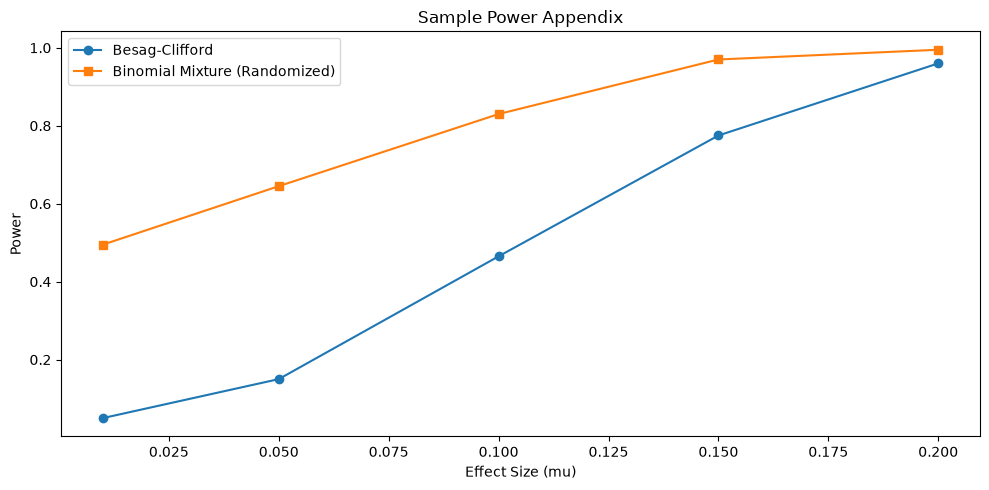

Generating Sample P-value Data...


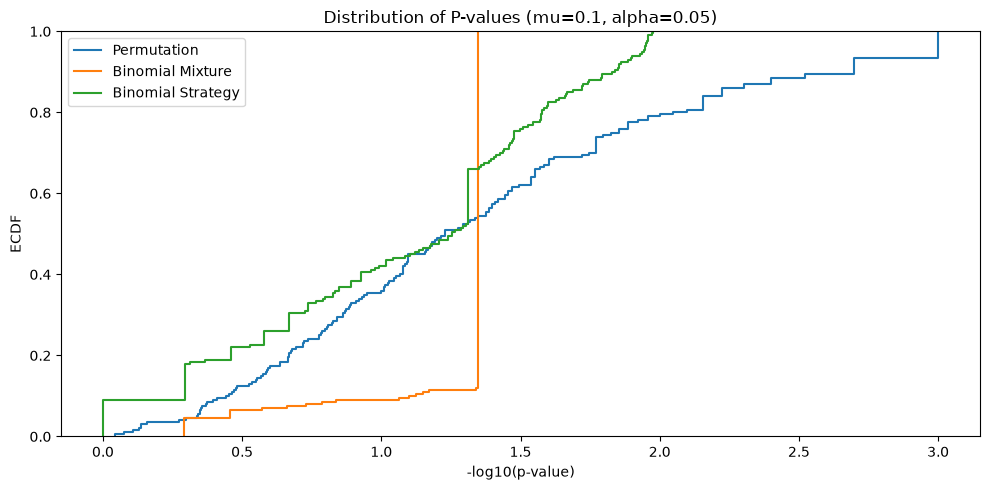

In [4]:
mus = [0.01, 0.05, 0.1, 0.15, 0.2]

print("Generating Sample Power Data...")
df_power = generate_power_data(alpha=0.05, c_param=0.05*0.9, futility_stop=0.05, mus=mus, n=1000, dist="normal")

plt.figure(figsize=(10, 5))
plt.plot(mus, df_power['power_bc'], label='Besag-Clifford', marker='o')
plt.plot(mus, df_power['power_bm_r'], label='Binomial Mixture (Randomized)', marker='s')
plt.xlabel("Effect Size (mu)")
plt.ylabel("Power")
plt.title("Sample Power Appendix")
plt.legend()
plt.tight_layout()
plt.savefig("appendix/results/sample_appendix_power.png")
plt.show()

print("Generating Sample P-value Data...")
data_logp(mu=0.1, alpha=0.05, filename="appendix/results/pval_alpha005_mu01.pkl")
with open("appendix/results/pval_alpha005_mu01.pkl", "rb") as f:
    res = pickle.load(f)

# Plot eCDF of -log10(p-value)
plt.figure(figsize=(10, 5))
for key, label in [('p_perm', 'Permutation'), ('p_bm', 'Binomial Mixture'), ('p_bin', 'Binomial Strategy')]:
    log_p = -np.log10(np.clip(res[key], 1e-10, 1.0))
    sns.ecdfplot(log_p, label=label)

plt.xlabel("-log10(p-value)")
plt.ylabel("ECDF")
plt.title("Distribution of P-values (mu=0.1, alpha=0.05)")
plt.legend()
plt.tight_layout()
plt.savefig("appendix/results/sample_appendix_pval.png")
plt.show()